<a href="https://colab.research.google.com/github/Cyberbullying-Detection-System-CDS/Image-and-Meme-Based-Cyber-bullying-and-Hate-Speech-Detection--Nethmi/blob/Developer/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 2: Imports and mount Google Drive
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import timm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim.lr_scheduler import ReduceLROnPlateau
import shutil

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# Cell 3: Load paths from your balanced folders
CYBER_FOLDER    = '/content/drive/MyDrive/augmented_cyberbullying/augmented_cyberbullying'
NON_CYBER_FOLDER = '/content/drive/MyDrive/downsampled_non_cyberbullying/downsampled_non_cyberbullying'

image_paths = []
labels = []

# Cyberbullying = 1
for fname in os.listdir(CYBER_FOLDER):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_paths.append(os.path.join(CYBER_FOLDER, fname))
        labels.append(1)

# Non-cyberbullying = 0
for fname in os.listdir(NON_CYBER_FOLDER):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_paths.append(os.path.join(NON_CYBER_FOLDER, fname))
        labels.append(0)

print(f"Total images loaded: {len(image_paths)}")
print(f"Cyberbullying (1): {sum(labels)}")
print(f"Non-cyberbullying (0): {len(labels) - sum(labels)}")

if len(image_paths) < 100:
    raise ValueError("Too few images loaded — check folder paths")

Total images loaded: 6001
Cyberbullying (1): 3001
Non-cyberbullying (0): 3000


In [ ]:
# Cell 4: Data transforms and custom Dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.18, hue=0.09),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CyberDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

In [ ]:
# Cell 5: Stratified-like split: 70% train, 15% val, 15% test
full_dataset = CyberDataset(image_paths, labels)

total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, temp_ds = random_split(full_dataset, [train_size, total - train_size])
val_ds,   test_ds = random_split(temp_ds,     [val_size, test_size])

# Apply correct transforms
train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = test_val_transform
test_ds.dataset.transform  = test_val_transform

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds):4d} images ({len(train_ds)/total*100:.1f}%)")
print(f"Val:   {len(val_ds):4d} images ({len(val_ds)/total*100:.1f}%)")
print(f"Test:  {len(test_ds):4d} images ({len(test_ds)/total*100:.1f}%)")

Train: 4200 images (70.0%)
Val:    900 images (15.0%)
Test:   901 images (15.0%)


In [ ]:
# Cell 6: Define EfficientNet-B0 with transfer learning
def get_model():
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=1)

    # Freeze backbone (standard transfer learning)
    for param in model.parameters():
        param.requires_grad = False

    # Custom head for binary classification
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
    )
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Cell 7: Train model with early stopping, save best checkpoint, show results
model = get_model().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
epochs = 60
patience = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_test_preds = []
best_test_labels = []
best_test_probs = []

for epoch in range(epochs):
    model.train()
    train_loss = train_correct = train_total = 0.0

    for inputs, lbls in train_loader:
        inputs, lbls = inputs.to(device), lbls.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == lbls).sum().item()
        train_total += lbls.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss = val_correct = val_total = 0.0

    with torch.no_grad():
        for inputs, lbls in val_loader:
            inputs, lbls = inputs.to(device), lbls.to(device).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {current_lr:.2e}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_state_dict.pth')
        torch.save(model, 'best_model_full.pth')
        patience_counter = 0
        print(f"  → New best (epoch {best_epoch}, val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("\nTraining finished. Best model from epoch", best_epoch)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch  1/60 | Train Loss: 0.6277 Acc: 0.6786 | Val Loss: 0.5639 Acc: 0.7422 | LR: 1.00e-04
  → New best (epoch 1, val loss: 0.5639)
Epoch  2/60 | Train Loss: 0.5370 Acc: 0.7395 | Val Loss: 0.5389 Acc: 0.7367 | LR: 1.00e-04
  → New best (epoch 2, val loss: 0.5389)
Epoch  3/60 | Train Loss: 0.5132 Acc: 0.7512 | Val Loss: 0.5264 Acc: 0.7367 | LR: 1.00e-04
  → New best (epoch 3, val loss: 0.5264)
Epoch  4/60 | Train Loss: 0.4987 Acc: 0.7600 | Val Loss: 0.5106 Acc: 0.7500 | LR: 1.00e-04
  → New best (epoch 4, val loss: 0.5106)
Epoch  5/60 | Train Loss: 0.4833 Acc: 0.7743 | Val Loss: 0.4849 Acc: 0.7867 | LR: 1.00e-04
  → New best (epoch 5, val loss: 0.4849)
Epoch  6/60 | Train Loss: 0.4794 Acc: 0.7705 | Val Loss: 0.4850 Acc: 0.7811 | LR: 1.00e-04
Epoch  7/60 | Train Loss: 0.4637 Acc: 0.7838 | Val Loss: 0.4920 Acc: 0.7578 | LR: 1.00e-04
Epoch  8/60 | Train Loss: 0.4499 Acc: 0.7881 | Val Loss: 0.4816 Acc: 0.7633 | LR: 1.00e-04
  → New best (epoch 8, val loss: 0.4816)
Epoch  9/60 | Train Loss: 


════════════════════════════════════════════════════════════════════════════════
FINAL PERFORMANCE – Unseen Test Set (15%)
Accuracy:    0.8013
Precision:   0.8412
Recall:      0.7602
F1-Score:    0.7987
AUC-ROC:     0.8877
Specificity: 0.8456
Confusion Matrix:
[[367  67]
 [112 355]]
════════════════════════════════════════════════════════════════════════════════


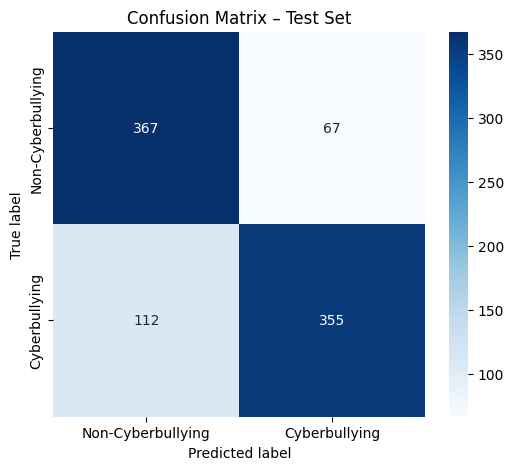

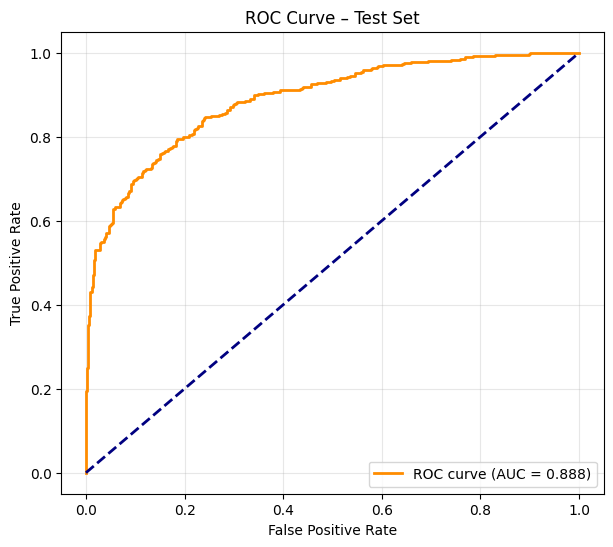

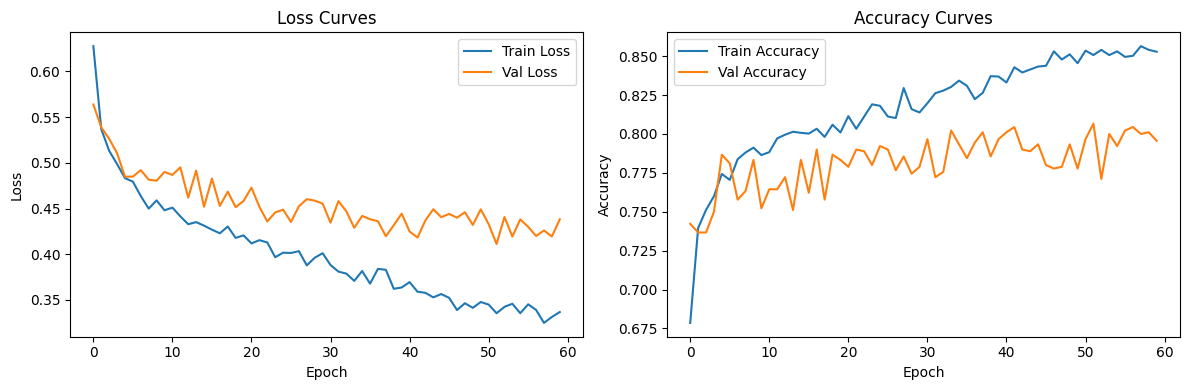

In [ ]:
# Cell 8: Final evaluation on held-out test set + plots
model.load_state_dict(torch.load('best_model_state_dict.pth', map_location=device))
model.eval()

test_loss = test_correct = test_total = 0.0
test_preds, test_labels_list, test_probs = [], [], []

with torch.no_grad():
    for inputs, lbls in test_loader:
        inputs, lbls = inputs.to(device), lbls.to(device).unsqueeze(1)
        outputs = model(inputs)
        loss = criterion(outputs, lbls)
        test_loss += loss.item() * inputs.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        test_correct += (preds == lbls).sum().item()
        test_total += lbls.size(0)

        test_preds.extend(preds.cpu().numpy().flatten())
        test_labels_list.extend(lbls.cpu().numpy().flatten())
        test_probs.extend(probs.cpu().numpy().flatten())

test_loss /= test_total
test_acc = test_correct / test_total

precision = precision_score(test_labels_list, test_preds, zero_division=0)
recall    = recall_score(test_labels_list, test_preds, zero_division=0)
f1        = f1_score(test_labels_list, test_preds, zero_division=0)
auc_score = roc_auc_score(test_labels_list, test_probs)

cm = confusion_matrix(test_labels_list, test_preds)

print("\n" + "═"*80)
print("FINAL PERFORMANCE – Unseen Test Set (15%)")
print(f"Accuracy:    {test_acc:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"AUC-ROC:     {auc_score:.4f}")
print(f"Specificity: {cm[0,0]/(cm[0,0]+cm[0,1]):.4f}" if (cm[0,0]+cm[0,1]) > 0 else "N/A")
print("Confusion Matrix:")
print(cm)
print("═"*80)

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Cyberbullying', 'Cyberbullying'],
            yticklabels=['Non-Cyberbullying', 'Cyberbullying'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Test Set')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels_list, test_probs)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Training history curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Save best model to Drive + download to computer
drive_folder = "/content/drive/MyDrive/cyberbullying_models"
os.makedirs(drive_folder, exist_ok=True)

shutil.copy('best_model_state_dict.pth', os.path.join(drive_folder, 'best_model_state_dict.pth'))
shutil.copy('best_model_full.pth',       os.path.join(drive_folder, 'best_model_full.pth'))

print(f"Models saved to: {drive_folder}")

from google.colab import files
files.download('best_model_full.pth')       # easier to load later
files.download('best_model_state_dict.pth') # smaller file

print("Models downloaded successfully!")

Models saved to: /content/drive/MyDrive/cyberbullying_models


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models downloaded successfully!
